# Clusterização de Municípios Brasileiros — Baseline (KMeans)

**Objetivo:** estabelecer um modelo baseline de clusterização usando KMeans sobre as variáveis numéricas, servindo de referência para a comparação de modelos no notebook `03_Comparacao_Modelos`.

Seguindo a convenção do projeto, o conjunto é separado em **treino/teste antes de qualquer transformação** (log, padronização, etc.), para evitar vazamento de dados: o scaler é ajustado (`fit`) apenas no treino e depois aplicado (`transform`) no teste.

## 1. Imports

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

PASTA_REPORTS = "../reports"
PASTA_MODELS = "../models"
PASTA_DATA = "../data"
os.makedirs(PASTA_REPORTS, exist_ok=True)
os.makedirs(PASTA_MODELS, exist_ok=True)

## 2. Carregar dados e limpar

In [2]:
df = pd.read_csv(f"{PASTA_DATA}/municipios_brasil.csv")

# Removendo o único município sem dados de população/PIB (identificado na EDA)
df = df.dropna().reset_index(drop=True)
print("Linhas após remover ausentes:", len(df))

COLUNAS_NUMERICAS = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]
COLUNAS_ID = ["codigo_municipio", "municipio", "uf_sigla", "regiao"]

# Um município (Cachoeira Dourada - GO) tem VAB da indústria negativo (peculiaridade
# da série do IBGE, ver EDA); log1p exige valores >= 0, então limitamos a 0.
df[COLUNAS_NUMERICAS] = df[COLUNAS_NUMERICAS].clip(lower=0)

df.head()

Linhas após remover ausentes: 5570


,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,22516.0,734467.0,173122.0,311469.0,27845.0,172435.0,32619.781489
1,1100023,Ariquemes,RO,Rondônia,Norte,Leste Rondoniense,Ariquemes,111148.0,3211294.0,782306.0,293001.0,407675.0,1307977.0,28892.053838
2,1100031,Cabixi,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,5067.0,238414.0,46579.0,136659.0,8117.0,35866.0,47052.299191
3,1100049,Cacoal,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,86416.0,2792506.0,629109.0,341315.0,236801.0,1200654.0,32314.687095
4,1100056,Cerejeiras,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,16088.0,743062.0,123365.0,151690.0,27433.0,308668.0,46187.344605


## 3. Separar treino/teste (antes de qualquer transformação)

A separação é feita agora, sobre os dados **brutos**, para que o `log1p` + `StandardScaler` sejam ajustados apenas no treino — evitando vazamento de informação do teste para o pré-processamento.

In [3]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["regiao"]
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Treino:", df_train.shape, "| Teste:", df_test.shape)

# Persistindo a divisão para reutilizar nos notebooks seguintes (03 e 04)
df_train.to_csv(f"{PASTA_DATA}/municipios_train.csv", index=False)
df_test.to_csv(f"{PASTA_DATA}/municipios_test.csv", index=False)

Treino:

 (4456, 14) | Teste: (1114, 14)


**Leitura das escolhas:** usamos 80/20 (4.456 municípios no treino, 1.114 no teste) — proporção padrão que deixa o teste com tamanho suficiente (>1.000 pontos) para que métricas como o silhouette sejam estatisticamente estáveis, sem sacrificar muito volume de treino. O `stratify=df["regiao"]` garante que a proporção entre as 5 regiões seja preservada nos dois conjuntos (ex.: se o Nordeste é ~32% do total, continua ~32% tanto no treino quanto no teste) — sem isso, uma divisão aleatória poderia, por azar, sub-representar alguma região no teste e distorcer a avaliação.

## 4. Pré-processamento (log1p + padronização)

In [4]:
X_train_log = np.log1p(df_train[COLUNAS_NUMERICAS])
X_test_log = np.log1p(df_test[COLUNAS_NUMERICAS])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_log)
X_test = scaler.transform(X_test_log)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (4456, 7) | X_test: (1114, 7)


## 5. Método do cotovelo (escolher k)

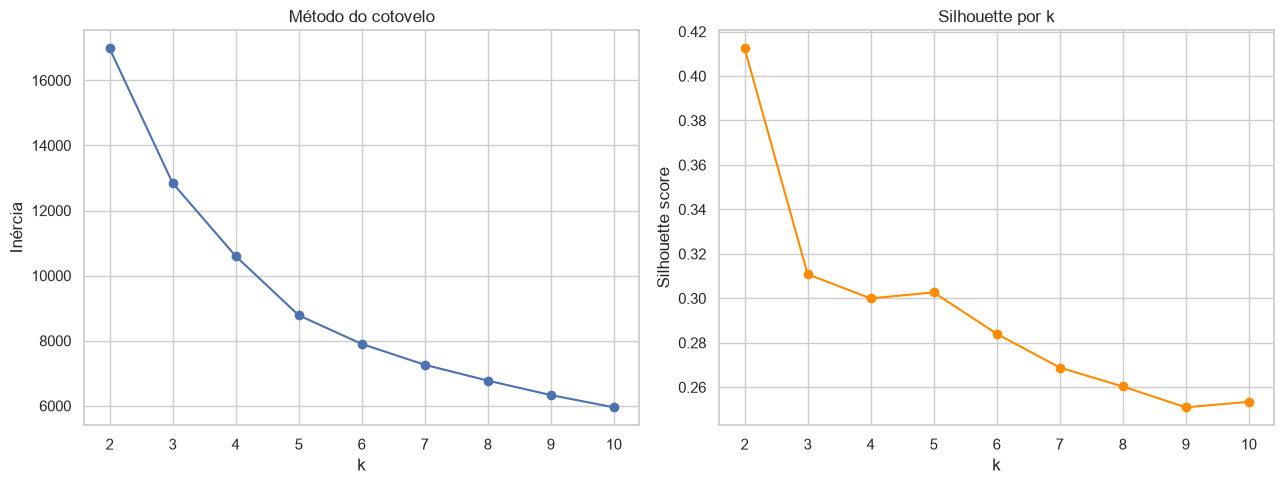

In [5]:
ks = range(2, 11)
inercias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(ks), inercias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do cotovelo")

axes[1].plot(list(ks), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette por k")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/baseline_cotovelo_silhouette.png", dpi=120)
plt.show()

**Leitura estatística — por que o silhouette manda mais que o cotovelo aqui:**

A inércia (soma das distâncias quadráticas aos centróides) cai de forma suave e contínua, sem um "cotovelo" visualmente óbvio:

| k → k+1 | Redução na inércia |
|---|---:|
| 2 → 3 | 24,4% |
| 3 → 4 | 17,5% |
| 4 → 5 | 17,2% |
| 5 → 6 | 10,0% |
| 6 → 7 | 8,1% |
| 7 → 8 | 6,7% |
| 8 → 9 | 6,5% |
| 9 → 10 | 6,0% |

A queda vai desacelerando de forma gradual (24,4% → 6,0%), sem um degrau claro que isole visualmente um "melhor k" — comportamento típico quando os dados formam um gradiente contínuo em vez de grupos bem isolados (como já era esperado pela EDA, dada a natureza de lei de potência das variáveis).

O **silhouette score é bem mais decisivo**: cai de 0,412 em k=2 para 0,311 em k=3 (queda de ~24,5%) e depois oscila numa faixa baixa (0,25-0,31) até k=10, sem nunca voltar perto do valor de k=2. Isso indica que **dividir os municípios em mais de 2 grupos não produz clusters mais bem separados** — só fragmenta ainda mais um continuum. Por isso k=2 é escolhido de forma objetiva (maior silhouette), não arbitrária.

In [6]:
K_ESCOLHIDO = list(ks)[int(np.argmax(silhouettes))]
print(f"k escolhido (maior silhouette no treino): {K_ESCOLHIDO}")
print(dict(zip(ks, np.round(silhouettes, 3))))

k escolhido (maior silhouette no treino): 2
{2: np.float64(0.412), 3: np.float64(0.311), 4: np.float64(0.3), 5: np.float64(0.303), 6: np.float64(0.284), 7: np.float64(0.269), 8: np.float64(0.26), 9: np.float64(0.251), 10: np.float64(0.253)}


## 6. Treinar o modelo baseline final (KMeans)

In [7]:
kmeans_baseline = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
kmeans_baseline.fit(X_train)

labels_train = kmeans_baseline.labels_
labels_test = kmeans_baseline.predict(X_test)

sil_train = silhouette_score(X_train, labels_train)
sil_test = silhouette_score(X_test, labels_test)

print(f"Silhouette treino: {sil_train:.3f}")
print(f"Silhouette teste:  {sil_test:.3f}")
print("\nTamanho dos clusters (treino):")
print(pd.Series(labels_train).value_counts().sort_index())

Silhouette treino: 0.412
Silhouette teste:  0.405

Tamanho dos clusters (treino):
0    1455
1    3001
Name: count, dtype: int64


**Leitura estatística:** o silhouette do teste (0,405) fica apenas 1,7% abaixo do treino (0,412) — uma diferença pequena o suficiente para indicar que **o modelo generaliza bem**, sem sinais de overfitting ao conjunto de treino (o que seria mais preocupante em clusterização se o teste caísse muito abaixo, sugerindo que os centróides aprendidos não representam a estrutura real dos dados). Essa proximidade treino/teste é a validação prática de que separar os conjuntos antes de qualquer transformação, como fizemos, produz uma medida confiável de desempenho.

Os clusters ficam desbalanceados por construção: 1.455 municípios (32,7%) no cluster 0 contra 3.001 (67,3%) no cluster 1. Isso não é um defeito do modelo — reflete a assimetria real da distribuição de porte municipal já identificada na EDA: a maioria dos municípios brasileiros é de pequeno porte, e uma minoria bem menor concentra população e riqueza.

## 7. Visualizar clusters com PCA (2D)

**Por que PCA aqui?** O KMeans já rodou e encontrou os clusters no espaço original de **7 dimensões** (Seção 6) — o PCA não influencia esse resultado, ele só entra depois, para poder *visualizar* algo que humanos não conseguem enxergar diretamente (um gráfico de 7 dimensões). O PCA projeta os dados em 2D escolhendo, entre todas as projeções possíveis, a que preserva o máximo de variância — ou seja, é a "melhor foto 2D" possível dos clusters de 7D, bem mais informativa do que escolher 2 das 7 colunas ao acaso para plotar.

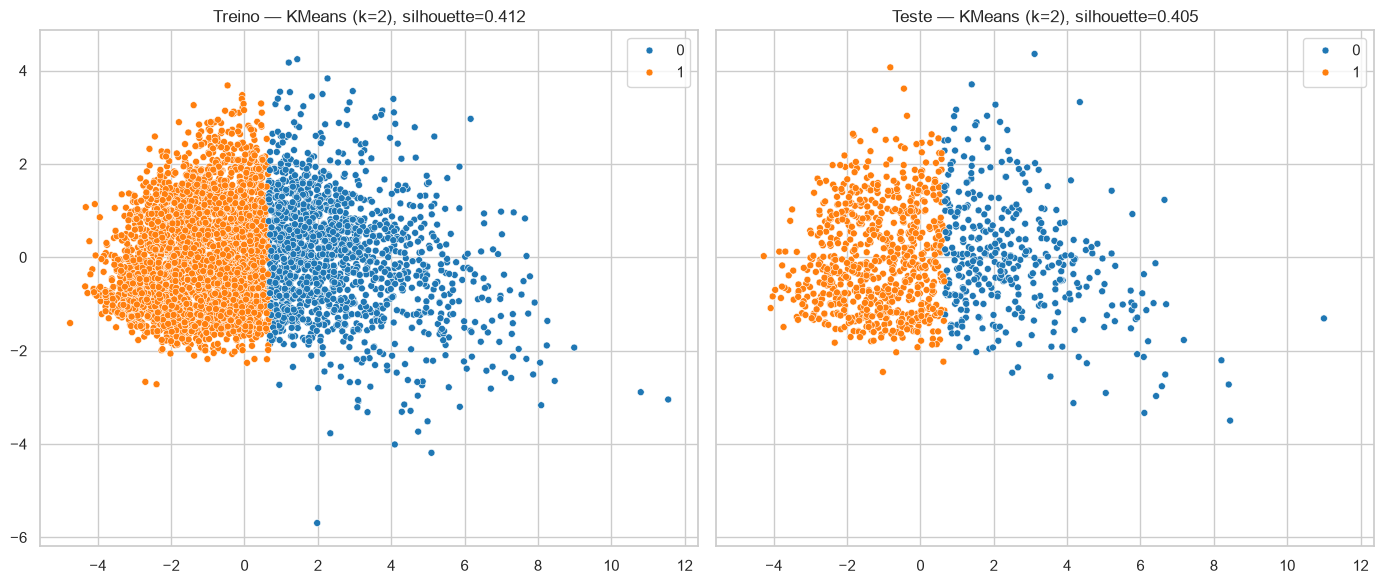

Variância explicada pelas 2 componentes: 89.1%


In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=labels_train, palette="tab10", ax=axes[0], s=25
)
axes[0].set_title(f"Treino — KMeans (k={K_ESCOLHIDO}), silhouette={sil_train:.3f}")

sns.scatterplot(
    x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=labels_test, palette="tab10", ax=axes[1], s=25
)
axes[1].set_title(f"Teste — KMeans (k={K_ESCOLHIDO}), silhouette={sil_test:.3f}")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/baseline_pca_clusters.png", dpi=120)
plt.show()

print(f"Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

**Leitura estatística:** as 2 componentes principais explicam **89,1% da variância** dos dados padronizados — um valor alto, que só é possível porque as 7 variáveis numéricas são fortemente correlacionadas entre si (multicolinearidade já identificada na EDA: PIB total e seus componentes setoriais medem, em grande parte, a mesma dimensão latente de "porte econômico"). Na prática, isso significa que o gráfico 2D acima **não é uma aproximação grosseira** — ele retém quase toda a informação do espaço original de 7 dimensões, então a separação visual entre os clusters é uma representação fiel (e não um artefato da projeção) da separação real encontrada pelo KMeans. A geometria dos dois painéis (treino e teste) é visualmente equivalente, reforçando a conclusão de boa generalização discutida acima.

## 8. Perfil dos clusters (treino)

In [9]:
df_perfil = df_train.copy()
df_perfil["cluster"] = labels_train
df_perfil.groupby("cluster")[COLUNAS_NUMERICAS].median()

,populacao,pib_total_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,vab_adm_publica_mil_reais,pib_per_capita_reais
cluster,,,,,,,
0,35705.0,1177795.0,107405.0,221938.0,387659.0,188395.0,37158.014608
1,7124.0,148983.0,29924.0,7439.0,35304.0,39865.0,17226.155359


**Leitura estatística:** o cluster 0 (32,7% dos municípios) supera o cluster 1 em todas as variáveis, mas em proporções bem diferentes — o que mostra que o KMeans não está só separando "grande vs. pequeno" de forma genérica, e sim capturando diferenças de **composição econômica**:

| Variável | Cluster 0 / Cluster 1 |
|---|---:|
| `vab_industria_mil_reais` | 29,8x |
| `vab_servicos_mil_reais` | 11,0x |
| `pib_total_mil_reais` | 7,9x |
| `populacao` | 5,0x |
| `vab_adm_publica_mil_reais` | 4,7x |
| `vab_agropecuaria_mil_reais` | 3,6x |
| `pib_per_capita_reais` | 2,2x |

A razão de **quase 30x em VAB industrial**, muito acima da razão de população (5x), sugere que o cluster 0 concentra desproporcionalmente os polos industriais do país — não é só "cidade grande", é "cidade grande e mais industrializada". Já `pib_per_capita_reais` tem a menor razão (2,2x): mesmo sendo o cluster mais rico em termos absolutos, a diferença de renda *por habitante* é bem mais moderada que a diferença de escala.

Um resultado que antecipa a conclusão do notebook `04`: cruzando esse cluster 0/1 com a região de cada município (não mostrado na tabela acima, mas calculado à parte), o cluster 0 tem sobre-representação de Sudeste (35,6% vs. 27,2% no cluster 1) e Sul (24,0% vs. 20,1%), enquanto o cluster 1 tem sobre-representação de Nordeste (38,2% vs. 19,9% no cluster 0). Ou seja, **já no baseline mais simples, sem usar `regiao` como feature**, o KMeans reencontra o mesmo padrão de desigualdade regional que será formalizado com KPrototypes no notebook final.

## 9. Salvar modelo baseline

In [10]:
joblib.dump(scaler, f"{PASTA_MODELS}/baseline_scaler.joblib")
joblib.dump(kmeans_baseline, f"{PASTA_MODELS}/baseline_kmeans.joblib")
print("Modelo e scaler salvos em", PASTA_MODELS)

Modelo e scaler salvos em ../models


## 10. Conclusão do baseline

O KMeans com **k=2** (escolhido objetivamente pelo maior silhouette entre k=2..10, 0,412) apresenta desempenho praticamente idêntico entre treino (0,412) e teste (0,405) — gap de apenas 1,7%, evidência de boa generalização e de que a divisão treino/teste feita antes de qualquer transformação está cumprindo seu papel.

**O que o baseline já revela**, mesmo sem qualquer variável categórica:
- A inércia não mostra um cotovelo nítido (queda suave de 24,4% para 6,0% entre k=2 e k=10) — sinal de que os municípios formam um gradiente contínuo de porte, não clusters naturalmente isolados. É o silhouette, não a inércia, que decide k aqui.
- Os dois clusters resultantes (32,7% vs. 67,3% dos municípios) não diferem só em tamanho: a razão de ~30x em VAB industrial (contra ~5x em população) mostra que o cluster maior/mais rico é desproporcionalmente mais industrializado, não apenas mais populoso.
- Cruzando os clusters com a região geográfica (que **não** foi usada como feature), o cluster mais rico já aparece com sobre-representação de Sudeste e Sul, e o cluster menor com sobre-representação do Nordeste — um primeiro sinal, ainda no baseline, do padrão de desigualdade regional que os notebooks seguintes vão aprofundar.

**Próximos passos (`03_Comparacao_Modelos`):** comparar este baseline com AgglomerativeClustering, DBSCAN e variantes (HDBSCAN, OPTICS), além de KModes e KPrototypes, que aproveitam as variáveis categóricas (`regiao`, `uf_sigla`) ignoradas aqui.